In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
pallete = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}

In [2]:
def frac_bin(df):
    total_sistemas = len(df)
    # Número de sistemas binários (comp_mass > 0)
    num_binarias = (df['comp_mass'] > 0).sum()
    return num_binarias/total_sistemas

# Leitura dos dados
data = pd.read_csv('data.csv', index_col='Cluster')
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col='Cluster')

In [3]:
aux = data[data.q>0]

In [6]:
aux.sort_values(by='q')[['q', 'er_q']]

,q,er_q
Cluster,,
IC_2948,0.005507,0.044923
Trumpler_14,0.007789,0.054737
NGC_7510,0.008253,0.067519
NGC_7510,0.010971,0.088936
Ruprecht_148,0.012016,0.070690
...,...,...
Berkeley_8,0.989049,0.012186
LP_866,0.989195,0.009963
NGC_581,0.989868,0.010974


In [5]:
aux.columns

Index(['pmRApmDEcor', 'PlxpmRAcor', 'PlxpmDEcor', 'RA_ICRS', 'e_RA_ICRS',
       'DE_ICRS', 'e_DE_ICRS', 'Plx', 'e_Plx', 'pmRA', 'e_pmRA', 'pmDE',
       'e_pmDE', 'Gmag', 'e_Gmag', 'BPmag', 'e_BPmag', 'RPmag', 'e_RPmag',
       'BPRP', 'RVDR2', 'e_RVDR2', 'EBPRP', 'Pmemb', 'mass', 'er_mass',
       'comp_mass', 'er_comp_mass', 'dist', 'e_dist', 'age', 'e_age', 'FeH',
       'e_FeH', 'Av', 'e_Av', 'Nc', 'alpha_high_int', 'alpha_high_er_int',
       'alpha_low_int', 'alpha_low_er_int', 'Mc_int', 'Mc_er_int',
       'offset_int', 'offset_er_int', 'q', 'er_q', 'mass_system',
       'e_mass_system', 'r', 'r/rh', 'e_r', 'e_r/rh'],
      dtype='object')

In [127]:
def classificar_massas(m):
    if m < 1:
        return 'Low mass'
    elif 1 <= m < 8:
        return 'Intermediate mass'
    else:
        return 'High mass'

# Aplicar a função e criar/atualizar coluna
aux['Companion group'] = aux['comp_mass'].apply(classificar_massas)

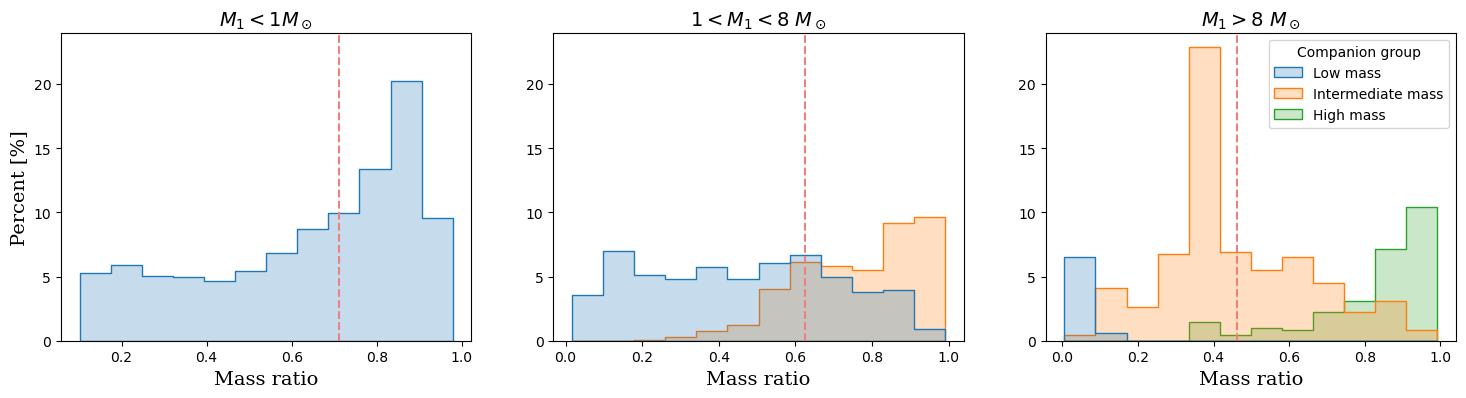

In [132]:
fig, axs = plt.subplots(1, 3 , figsize=(18,4), sharey='row')

sns.histplot(data =aux[aux.mass<1], x='q',  element='step', bins=12, stat= 'percent',  hue='Companion group', 
             ax=axs[0], legend=False)

axs[0].axvline(aux[aux.mass<1].q.median(), color='lightcoral', linestyle='--') 



sns.histplot(data =aux[(aux.mass>=1) & (aux.mass<8)], x='q',  element='step', bins=12,  stat= 'percent', hue='Companion group', 
             ax = axs[1], legend=False, hue_order=['Low mass', 'Intermediate mass'])

axs[1].axvline(aux[(aux.mass>=1) & (aux.mass<8)].q.median(), color='lightcoral', linestyle='--')


sns.histplot(data =aux[aux.mass>=8], x='q',  element='step', bins=12,   stat= 'percent', hue='Companion group', ax= axs[2],
            hue_order=['Low mass', 'Intermediate mass', 'High mass'])

axs[2].axvline(aux[aux.mass>=8].q.median(), color='lightcoral', linestyle='--')


for ax in axs:
    ax.set_xlabel('Mass ratio', fontdict = font)
    ax.tick_params(labelleft=True, labelbottom=True)

axs[0].set_ylabel('Percent [%]', fontdict=font)

axs[0].set_title(r'$M_1< 1 M_\odot$', fontdict=font)

axs[1].set_title(r'$1 < M_1 < 8~M_\odot$', fontdict=font)

axs[2].set_title(r'$M_1 >8~M_\odot$', fontdict=font)


plt.savefig('dist_mass_ratio_massa.png',bbox_inches='tight', dpi=300)
plt.show()

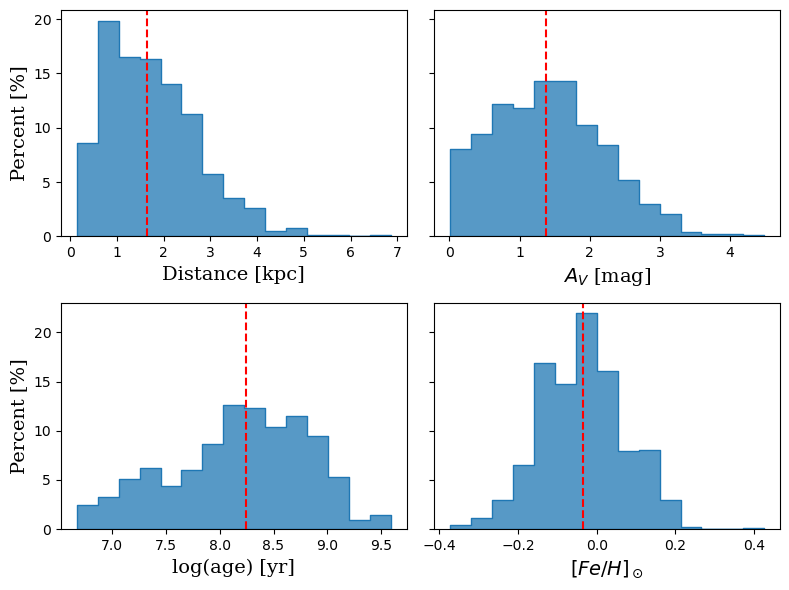

In [22]:
var = ['dist', 'Av','age', 'FeH']
label = ['Distance [kpc]', r'$A_V$ [mag]', 'log(age) [yr]', r'$[Fe/H]_\odot$']

row = 2
col = 2
fig, axs = plt.subplots(row, col, figsize=(8,6), sharey='row')

axs = axs.flatten()

for i in range(len(var)):
    sns.histplot(data=df, x=var[i], ax=axs[i], element='step', stat='percent', bins=15)
    axs[i].axvline(df[var[i]].median(), color='red', linestyle='--', label='Median')
    axs[i].set_xlabel(label[i], fontdict=font)
    axs[i].set_ylabel("Percent [%]", fontdict=font) 

plt.tight_layout()
plt.savefig('clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()

    


In [ ]:
plt.axvline